# Probability Distributions in AI/ML - Practice Notebook

This notebook contains conceptual and coding questions on Normal, Binomial, and Poisson distributions.

---

## 1. Normal Distribution

**Q1:** Generate a normal distribution with mean=0 and std=1. Plot it.

**Q2:** Simulate exam scores of 1000 students assuming normal distribution. What percentage scored above 85?

**Q3 (Thinking):** How does changing standard deviation affect the spread? Visualize.

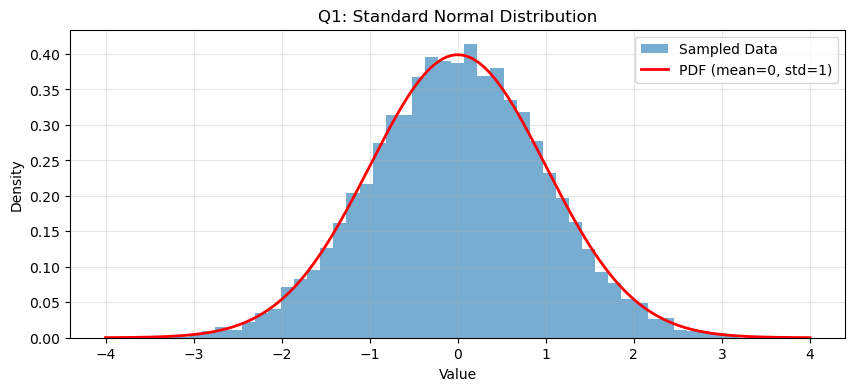

Q2: Percentage of students scoring above 85: 7.10%
    Theoretical: 6.68%


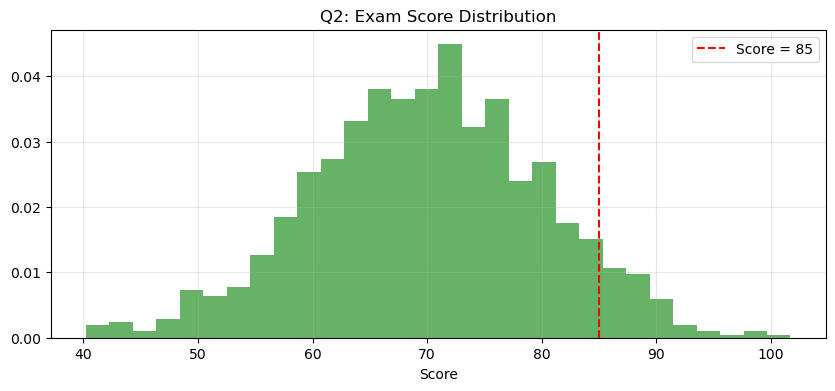

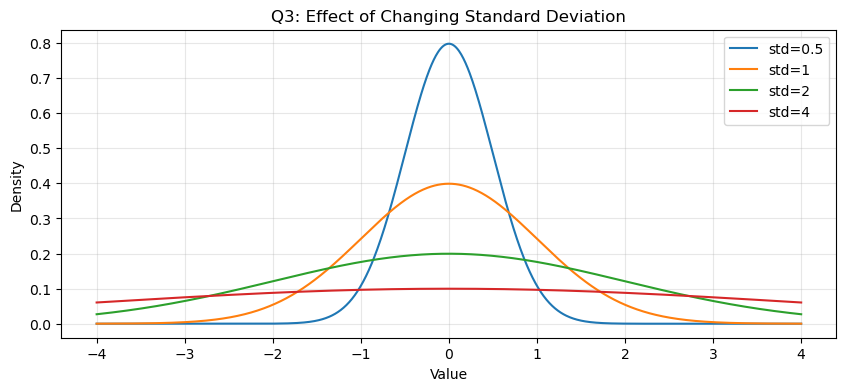

Q3: Larger std -> wider/flatter curve; smaller std -> taller/narrower curve.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Q1: Normal distribution with mean=0, std=1
data = np.random.normal(loc=0, scale=1, size=10000)
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, 0, 1)

plt.figure(figsize=(10, 4))
plt.hist(data, bins=50, density=True, alpha=0.6, label='Sampled Data')
plt.plot(x, pdf, 'r-', linewidth=2, label='PDF (mean=0, std=1)')
plt.title('Q1: Standard Normal Distribution')
plt.xlabel('Value'); plt.ylabel('Density')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Q2: Exam scores - mean=70, std=10
scores = np.random.normal(loc=70, scale=10, size=1000)
pct_above_85 = np.mean(scores > 85) * 100
print(f'Q2: Percentage of students scoring above 85: {pct_above_85:.2f}%')
print(f'    Theoretical: {(1 - stats.norm.cdf(85, 70, 10)) * 100:.2f}%')

plt.figure(figsize=(10, 4))
plt.hist(scores, bins=30, density=True, alpha=0.6, color='green')
plt.axvline(85, color='red', linestyle='--', label='Score = 85')
plt.title('Q2: Exam Score Distribution'); plt.xlabel('Score')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Q3: Effect of changing standard deviation
plt.figure(figsize=(10, 4))
for sd in [0.5, 1, 2, 4]:
    plt.plot(x, stats.norm.pdf(x, 0, sd), label=f'std={sd}')
plt.title('Q3: Effect of Changing Standard Deviation')
plt.xlabel('Value'); plt.ylabel('Density')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()
print('Q3: Larger std -> wider/flatter curve; smaller std -> taller/narrower curve.')

## 2. Binomial Distribution

**Q4:** Simulate 100 coin toss experiments with probability p=0.5. Plot distribution.

**Q5:** Model a scenario where a student guesses MCQs (4 options). What is probability of getting exactly 6 correct out of 10?

**Q6 (Thinking):** When does binomial start resembling normal distribution? Demonstrate.

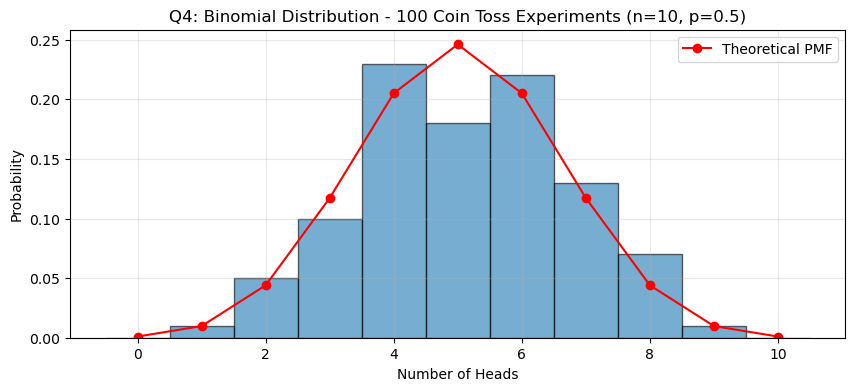

Q5: P(exactly 6 correct out of 10 by guessing) = 0.016222 (1.6222%)


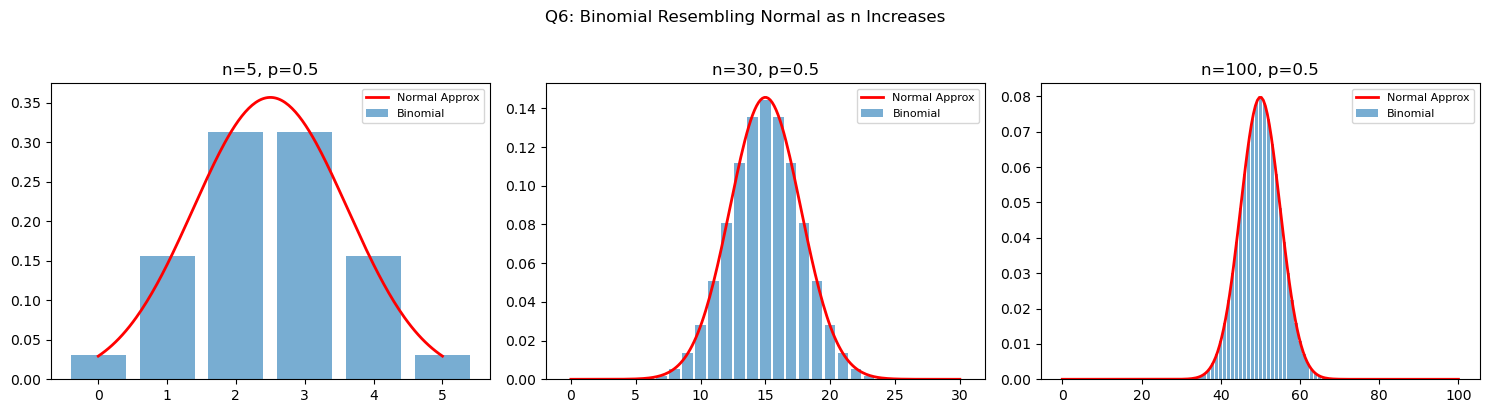

Q6: As n increases, Binomial(n,p) approaches Normal(np, np(1-p)). Rule of thumb: np >= 5 and n(1-p) >= 5.


In [2]:
# Q4: 100 coin tosses
n_trials = 10  # tosses per experiment
results = np.random.binomial(n=n_trials, p=0.5, size=100)

plt.figure(figsize=(10, 4))
plt.hist(results, bins=range(0, n_trials+2), density=True, alpha=0.6,
         edgecolor='black', align='left')
# overlay PMF
k_vals = np.arange(0, n_trials+1)
pmf = stats.binom.pmf(k_vals, n_trials, 0.5)
plt.plot(k_vals, pmf, 'ro-', label='Theoretical PMF')
plt.title('Q4: Binomial Distribution - 100 Coin Toss Experiments (n=10, p=0.5)')
plt.xlabel('Number of Heads'); plt.ylabel('Probability')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Q5: MCQ guessing - p=1/4, n=10, k=6
p_mcq = 1/4
prob_6 = stats.binom.pmf(6, 10, p_mcq)
print(f'Q5: P(exactly 6 correct out of 10 by guessing) = {prob_6:.6f} ({prob_6*100:.4f}%)')

# Q6: Binomial approaches Normal when n is large
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, n in zip(axes, [5, 30, 100]):
    k = np.arange(0, n+1)
    binom_pmf = stats.binom.pmf(k, n, 0.5)
    ax.bar(k, binom_pmf, alpha=0.6, label='Binomial')
    # overlay normal approximation
    mu, sigma = n*0.5, np.sqrt(n*0.5*0.5)
    x_norm = np.linspace(0, n, 200)
    ax.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), 'r-', lw=2, label='Normal Approx')
    ax.set_title(f'n={n}, p=0.5')
    ax.legend(fontsize=8)
plt.suptitle('Q6: Binomial Resembling Normal as n Increases', y=1.02)
plt.tight_layout(); plt.show()
print('Q6: As n increases, Binomial(n,p) approaches Normal(np, np(1-p)). Rule of thumb: np >= 5 and n(1-p) >= 5.')

## 3. Poisson Distribution

**Q7:** Model number of calls received per minute in a call center (lambda=5).

**Q8:** What is probability of receiving exactly 3 calls in a minute?

**Q9 (Thinking):** When should Poisson be used instead of Binomial? Simulate example.

In [ ]:
# Q7: Poisson distribution lambda=5
calls = np.random.poisson(lam=5, size=1000)
k_vals = np.arange(0, 16)

plt.figure(figsize=(10, 4))
plt.hist(calls, bins=range(0, 17), density=True, alpha=0.6, edgecolor='black', align='left')
plt.plot(k_vals, stats.poisson.pmf(k_vals, 5), 'ro-', label='Theoretical PMF')
plt.title('Q7: Poisson Distribution - Calls per Minute (λ=5)')
plt.xlabel('Number of Calls'); plt.ylabel('Probability')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Q8: P(X=3) when lambda=5
prob_3 = stats.poisson.pmf(3, 5)
print(f'Q8: P(exactly 3 calls) = {prob_3:.6f} ({prob_3*100:.4f}%)')

# Q9: Poisson vs Binomial
# Use Poisson when n is large and p is very small (rare events)
n_large = 1000; p_small = 0.005  # lambda = n*p = 5
binom_samples = np.random.binomial(n_large, p_small, 10000)
poisson_samples = np.random.poisson(lam=n_large*p_small, size=10000)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(binom_samples, bins=range(0, 20), density=True, alpha=0.6, edgecolor='black', align='left')
axes[0].set_title('Binomial(n=1000, p=0.005)')
axes[1].hist(poisson_samples, bins=range(0, 20), density=True, alpha=0.6, edgecolor='black', align='left', color='orange')
axes[1].set_title('Poisson(λ=5)')
plt.suptitle('Q9: Poisson Approximation of Binomial (rare events)'); plt.tight_layout(); plt.show()
print('Q9: Use Poisson when n is large & p is small (rare events). Poisson is simpler and approximates Binomial well.')

## 4. Real-world Modeling + Pipeline

**Q10:** Create synthetic dataset where target follows a distribution.

**Q11:** Build a pipeline using sklearn that:
- Generates features
- Scales data
- Fits a model

**Q12 (Challenge):** Identify which distribution best fits given dataset.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Q10: Synthetic dataset - target follows normal distribution
np.random.seed(42)
X = np.random.rand(500, 3)  # 3 features
y = 2*X[:, 0] + 3*X[:, 1] - X[:, 2] + np.random.normal(0, 0.5, 500)  # normal noise
print(f'Q10: Dataset shape: X={X.shape}, y={y.shape}')
print(f'     Target mean={y.mean():.3f}, std={y.std():.3f}')

# Q11: Sklearn Pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])
pipe.fit(X_train, y_train)
score = pipe.score(X_test, y_test)
print(f'Q11: Pipeline R² score = {score:.4f}')

# Q12: Identify best fitting distribution
from scipy.stats import shapiro, kstest
test_data = np.random.normal(5, 2, 500)

# Shapiro-Wilk test for normality
stat, p_val = shapiro(test_data[:200])  # limited to 200 for shapiro
print(f'Q12: Shapiro-Wilk test: stat={stat:.4f}, p-value={p_val:.4f}')
print(f'     Normal fit? {"Yes" if p_val > 0.05 else "No"} (p > 0.05 means normal)')

# Compare distributions visually
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_data, bins=30, density=True, alpha=0.6, label='Data')
x_fit = np.linspace(test_data.min(), test_data.max(), 200)
mu_fit, std_fit = stats.norm.fit(test_data)
ax.plot(x_fit, stats.norm.pdf(x_fit, mu_fit, std_fit), 'r-', lw=2, label=f'Normal(μ={mu_fit:.2f}, σ={std_fit:.2f})')
ax.set_title('Q12: Distribution Fitting'); ax.legend(); plt.grid(True, alpha=0.3); plt.show()

## 🚨 Mini Project: Fraud Detection using Poisson Anomalies

A payment system records number of transactions per minute.

**Q13:** Simulate normal transaction behavior (λ = 5).

**Q14:** Inject anomalies (fraud spikes).

**Q15:** Detect anomalies using Poisson probability threshold.

**Q16 (Thinking):** How would you reduce false positives?


In [ ]:
np.random.seed(0)

# Q13: Normal transaction behavior
normal_transactions = np.random.poisson(lam=5, size=100)

# Q14: Inject anomalies (fraud spikes at indices 20, 50, 80)
transactions = normal_transactions.copy()
fraud_indices = [20, 50, 80]
for i in fraud_indices:
    transactions[i] = np.random.randint(15, 25)  # unusually high

plt.figure(figsize=(12, 4))
plt.plot(transactions, 'b-', alpha=0.7, label='Transactions')
plt.scatter(fraud_indices, transactions[fraud_indices], color='red', s=100, zorder=5, label='Injected Anomalies')
plt.title('Q13-Q14: Transaction Data with Injected Anomalies')
plt.xlabel('Minute'); plt.ylabel('# Transactions')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# Q15: Detect anomalies using Poisson probability threshold
lam = 5
threshold = 0.001  # if P(X >= x) < threshold, flag as anomaly
anomaly_flags = []
for i, t in enumerate(transactions):
    p = 1 - stats.poisson.cdf(t - 1, lam)  # P(X >= t)
    if p < threshold:
        anomaly_flags.append(i)

print(f'Q15: Detected anomalies at minutes: {anomaly_flags}')
print(f'     Actual fraud at minutes: {fraud_indices}')

plt.figure(figsize=(12, 4))
plt.plot(transactions, 'b-', alpha=0.7)
plt.scatter(anomaly_flags, transactions[anomaly_flags], color='red', s=100, marker='x', linewidths=3, label='Detected Anomalies')
plt.axhline(y=stats.poisson.ppf(1 - threshold, lam), color='orange', linestyle='--', label=f'Threshold boundary')
plt.title('Q15: Anomaly Detection Results'); plt.xlabel('Minute'); plt.ylabel('# Transactions')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

print('\nQ16 (Thinking): Ways to reduce false positives:')
print('  1. Use a sliding window average instead of single-minute checks')
print('  2. Adjust threshold dynamically based on time-of-day patterns')
print('  3. Require consecutive anomalous minutes before flagging')
print('  4. Combine with other features (amount, location) for multi-variate detection')

## 🎛 Interactive Visualization (ipywidgets)

**Q17:** Create sliders for:
- Mean (μ)
- Standard deviation (σ)
- Lambda (λ)

Plot distributions dynamically.


In [ ]:
# Q17: Interactive Visualization using ipywidgets
try:
    from ipywidgets import interact, FloatSlider, IntSlider

    def plot_distributions(mu=0, sigma=1, lam=5):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Normal distribution
        x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
        axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'b-', lw=2)
        axes[0].fill_between(x, stats.norm.pdf(x, mu, sigma), alpha=0.3)
        axes[0].set_title(f'Normal(μ={mu}, σ={sigma})')
        axes[0].set_ylabel('Density'); axes[0].grid(True, alpha=0.3)

        # Poisson distribution
        k = np.arange(0, max(20, int(lam*3)))
        axes[1].bar(k, stats.poisson.pmf(k, lam), alpha=0.6, color='orange')
        axes[1].set_title(f'Poisson(λ={lam})')
        axes[1].set_ylabel('Probability'); axes[1].grid(True, alpha=0.3)

        plt.tight_layout(); plt.show()

    interact(plot_distributions,
             mu=FloatSlider(min=-10, max=10, step=0.5, value=0, description='Mean μ'),
             sigma=FloatSlider(min=0.1, max=5, step=0.1, value=1, description='Std σ'),
             lam=IntSlider(min=1, max=20, step=1, value=5, description='Lambda λ'))
except ImportError:
    print('ipywidgets not installed. Install with: pip install ipywidgets')
    # Static fallback
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    x = np.linspace(-4, 4, 300)
    axes[0].plot(x, stats.norm.pdf(x, 0, 1), 'b-', lw=2)
    axes[0].fill_between(x, stats.norm.pdf(x, 0, 1), alpha=0.3)
    axes[0].set_title('Normal(μ=0, σ=1)'); axes[0].grid(True, alpha=0.3)
    k = np.arange(0, 16)
    axes[1].bar(k, stats.poisson.pmf(k, 5), alpha=0.6, color='orange')
    axes[1].set_title('Poisson(λ=5)'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

## 📊 Distribution Fitting

**Q18:** Given a dataset, fit Normal, Poisson, and Binomial distributions.

**Q19:** Use likelihood or visual comparison to decide best fit.


In [ ]:
# Q18 & Q19: Distribution Fitting
np.random.seed(42)
# Generate data from a known Poisson distribution
sample_data = np.random.poisson(lam=7, size=500)

# Fit Normal
mu_n, std_n = stats.norm.fit(sample_data)
# Fit Poisson (MLE: lambda = mean)
lam_p = sample_data.mean()

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_range = np.arange(0, 20)

# Histogram
for ax in axes:
    ax.hist(sample_data, bins=range(0, 21), density=True, alpha=0.5, edgecolor='black', align='left', label='Data')
    ax.grid(True, alpha=0.3)

# Normal fit
x_cont = np.linspace(0, 20, 200)
axes[0].plot(x_cont, stats.norm.pdf(x_cont, mu_n, std_n), 'r-', lw=2, label=f'Normal(μ={mu_n:.1f}, σ={std_n:.1f})')
axes[0].set_title('Normal Fit'); axes[0].legend(fontsize=8)

# Poisson fit
axes[1].plot(x_range, stats.poisson.pmf(x_range, lam_p), 'go-', lw=2, label=f'Poisson(λ={lam_p:.1f})')
axes[1].set_title('Poisson Fit'); axes[1].legend(fontsize=8)

# Binomial fit (n=20, p estimated from data)
n_binom = 20
p_binom = sample_data.mean() / n_binom
axes[2].plot(x_range, stats.binom.pmf(x_range, n_binom, p_binom), 'ms-', lw=2, label=f'Binomial(n={n_binom}, p={p_binom:.2f})')
axes[2].set_title('Binomial Fit'); axes[2].legend(fontsize=8)

plt.suptitle('Q18-Q19: Distribution Fitting Comparison'); plt.tight_layout(); plt.show()

# Log-likelihood comparison
ll_normal = np.sum(stats.norm.logpdf(sample_data, mu_n, std_n))
ll_poisson = np.sum(stats.poisson.logpmf(sample_data, lam_p))
ll_binom = np.sum(stats.binom.logpmf(sample_data, n_binom, p_binom))

print('Q19: Log-Likelihood Comparison (higher = better fit):')
print(f'  Normal:   {ll_normal:.2f}')
print(f'  Poisson:  {ll_poisson:.2f}')
print(f'  Binomial: {ll_binom:.2f}')
best = max([('Normal', ll_normal), ('Poisson', ll_poisson), ('Binomial', ll_binom)], key=lambda x: x[1])
print(f'  Best fit: {best[0]}')

## 🌍 Real Dataset Integration

**Q20:** Load real dataset (e.g., traffic, rainfall, or stock data).

**Q21:** Identify which distribution best models the data.

**Q22 (Challenge):** Build a small ML model using this dataset.


In [ ]:
# Q20-Q22: Using sklearn's built-in California Housing dataset
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Q20: Load dataset
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
print(f'Q20: California Housing Dataset loaded')
print(f'     Features: {housing.feature_names}')
print(f'     Shape: X={X_h.shape}, y={y_h.shape}')

# Q21: Identify distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_h, bins=50, density=True, alpha=0.6, edgecolor='black')
mu_h, std_h = stats.norm.fit(y_h)
x_h = np.linspace(y_h.min(), y_h.max(), 200)
axes[0].plot(x_h, stats.norm.pdf(x_h, mu_h, std_h), 'r-', lw=2, label=f'Normal(μ={mu_h:.2f}, σ={std_h:.2f})')
axes[0].set_title('Q21: House Price Distribution + Normal Fit')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# QQ plot
stats.probplot(y_h, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout(); plt.show()

stat_h, p_h = stats.normaltest(y_h)
print(f'Q21: Normality test p-value = {p_h:.6f}')
print(f'     Data is {"NOT " if p_h < 0.05 else ""}normally distributed (right-skewed with cap at 5.0)')

# Q22: Build ML model
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

pipe_h = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])
pipe_h.fit(X_train_h, y_train_h)
y_pred_h = pipe_h.predict(X_test_h)

print(f'\nQ22: Random Forest Model Results:')
print(f'     R² Score: {r2_score(y_test_h, y_pred_h):.4f}')
print(f'     RMSE: {np.sqrt(mean_squared_error(y_test_h, y_pred_h)):.4f}')

# Feature importance
importances = pipe_h.named_steps['model'].feature_importances_
plt.figure(figsize=(10, 4))
plt.barh(housing.feature_names, importances, color='teal', alpha=0.7)
plt.title('Q22: Feature Importance - Random Forest')
plt.xlabel('Importance'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()